# CAP 4611 – Algorithms for Machine Learning · Spring 2026

## CAP 4611 – Assignment 4: KMeans Clustering


## Section 1 – Load Data and Perform Basic EDA

In this section we import all necessary libraries, load the dataset, inspect its shape, check for nulls, verify data types, and plot a correlation heatmap.

### Section 1.1 - Import Necessary Libraries (5 pts)

In [1]:
# ── IMPORTS ────────────────────────────────────────────────────────────────
# numpy  → fast array math (used internally by sklearn and pandas)
import numpy as np

# pandas → DataFrame: the main structure we'll store our data in
import pandas as pd

# matplotlib → the base plotting library in Python
import matplotlib.pyplot as plt

# seaborn → built on top of matplotlib; makes statistical plots easier/prettier
import seaborn as sns

# StandardScaler → scales features so they all have mean=0 and std=1
from sklearn.preprocessing import StandardScaler

# KMeans → the main clustering algorithm for Section 3
from sklearn.cluster import KMeans

# AgglomerativeClustering → hierarchical clustering for Section 4
from sklearn.cluster import AgglomerativeClustering

# confusion_matrix, classification_report → evaluate our clusters vs ground truth
from sklearn.metrics import confusion_matrix, classification_report

# dendrogram, linkage → used to build and draw the tree diagram in Section 4
from scipy.cluster.hierarchy import dendrogram, linkage

# Tell Jupyter to show plots inline (inside the notebook, not a pop-up window)
%matplotlib inline

# Apply a clean background style to all seaborn plots
sns.set_theme(style='whitegrid')

### Section 1.2 - Import The Data to Pandas Dataframe and Show The Count of Rows and Columns (1 pt)

In [2]:
# pd.read_csv() reads the CSV file from disk into a pandas DataFrame
# index_col=0 absorbs the first column (an unnamed row-number column saved
# when the file was exported) so it doesn't show up as a data column
df = pd.read_csv('hrdata3.csv', index_col=0)

# .shape gives us a tuple: (rows, columns)
num_rows, num_cols = df.shape

print(f'Number of rows      : {num_rows}')
print(f'Number of Columns   : {num_cols}')

Number of rows      : 12977
Number of Columns   : 7


### Section 1.3 - Show Top 5 and Last 5 Rows (1 pt)

In [3]:
# .head() returns the first 5 rows by default
# This lets us see the column names and what the data actually looks like
print('=== TOP 5 ROWS ===')
display(df.head())

# .tail() returns the last 5 rows
# Useful to confirm the data doesn't have any junk rows at the bottom
print('=== LAST 5 ROWS ===')
display(df.tail())

=== TOP 5 ROWS ===


,enrollee_id,city_development_index,experience,company_size,last_new_job,training_hours,target
1,29725,0.776,15,2,5,47,0.0
4,666,0.767,21,2,4,8,0.0
6,28806,0.920,5,2,1,24,0.0
7,402,0.762,13,0,5,18,1.0
8,27107,0.920,7,2,1,46,1.0


=== LAST 5 ROWS ===


,enrollee_id,city_development_index,experience,company_size,last_new_job,training_hours,target
19149,251,0.920,9,2,1,36,1.0
19150,32313,0.920,10,3,3,23,0.0
19152,29754,0.920,7,1,1,25,0.0
19155,24576,0.920,21,2,4,44,0.0
19156,5756,0.802,0,4,2,97,0.0


### Section 1.4 - Checking for Null Values

In [4]:
# .isnull() returns True wherever a cell is missing
# .sum() counts the Trues per column → gives us the null count per column
null_counts = df.isnull().sum()

print('Null value count per column:')
print(null_counts)

# Overall check: if all counts are 0 there are no missing values at all
if null_counts.sum() == 0:
    print('\n✓ No Null Values Found - Safe to Proceed.')
else:
    print(f'\n⚠ Total Nulls: {null_counts.sum()} - handle before clustering.')

Null value count per column:
enrollee_id               0
city_development_index    0
experience                0
company_size              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

✓ No Null Values Found - Safe to Proceed.


### Section 1.5 - Verify All Columns Are Numeric and Convert if Needed

In [5]:
# KMeans only works on numbers — it can't handle text or category columns
# .dtypes shows the data type of every column
print('Column data types:')
print(df.dtypes)

# select_dtypes(exclude=[...]) pulls only columns that are NOT int or float
non_numeric = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

if non_numeric:
    # If any non-numeric columns exist, convert them using pd.to_numeric()
    # errors='coerce' turns any value that can't convert into NaN instead of crashing
    print(f'\nNon-numeric columns found: {non_numeric}')
    print('Converting...')
    for col in non_numeric:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    print('\nUpdated data types:')
    print(df.dtypes)
else:
    print('\n✓ All columns are already numeric - no conversion needed.')

Column data types:
enrollee_id                 int64
city_development_index    float64
experience                  int64
company_size                int64
last_new_job                int64
training_hours              int64
target                    float64
dtype: object

✓ All columns are already numeric - no conversion needed.


### Section 1.6 - Plot Correlation Heatmap

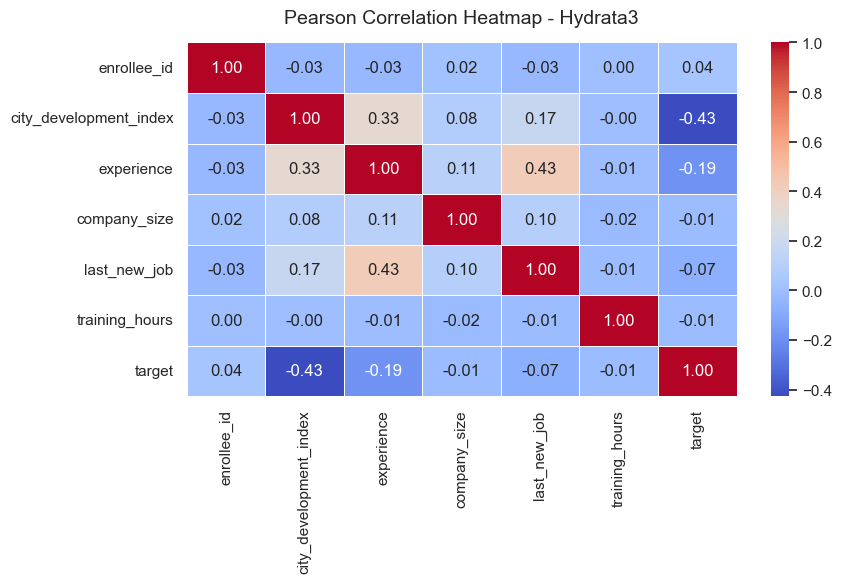

In [6]:
# A correlation heatmap shows the linear relationship between every pair of columns
# Values range from -1 (perfect negative) to +1 (perfect positive), 0 = no relationship
# This helps us understand which features move together before we cluster

fig, ax = plt.subplots(figsize=(9,6))

# .corr() computes the Pearson correlation matrix (every column vs every other column)
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,         # Print the actual number inside each cell
    fmt='.2f',          # Round to 2 decimal places 
    cmap='coolwarm',    # Blue = negative correlation, Red = positive correlation
    linewidths=0.5,     # Thin lines between cells for readability
    ax=ax
)

ax.set_title('Pearson Correlation Heatmap - Hydrata3', fontsize=14, pad=14)
plt.tight_layout()
plt.show()

## Section 2 - Feature Selection and Pre-processing (total 4 pts (1.5 + 2.5 = 4 pts))
- In this section we will build our feature matrix X by removing columns that 
should not be used for clustering, then apply StandardScaler to normalize 
every feature so that KMeans treats them all equally when computing distances.
    - - Showing sample after scaling is 1 pt and performing scaling is 1.5 pts

### SECTION 2.1 : BUILD FEATURE MATRIX X

In [7]:
# We drop two columns before clustering:
#
#   'enrollee_id' → just a unique ID number assigned to each candidate
#                   it has no relationship to job-seeking behavior
#                   including it would add meaningless distance noise
#
#   'target'      → this is our ground truth label (0.0 = not seeking job,
#                   1.0 = seeking job). We exclude it because KMeans is
#                   unsupervised — it must find structure on its own without
#                   being told the correct answer
#
# .drop(columns=[...]) removes those columns and returns the rest as X

X = df.drop(columns=['enrollee_id', 'target'])

# Confirm the shape and columns that made it into X
print("Feature matrix X shape:", X.shape)
print("\nColumns included in X:")
print(X.columns.tolist())

# Show the first 5 rows so we can visually confirm what X looks like
print('\nFirst 5 Rows of X:')
display(X.head(10))

Feature matrix X shape: (12977, 5)

Columns included in X:
['city_development_index', 'experience', 'company_size', 'last_new_job', 'training_hours']

First 5 Rows of X:


,city_development_index,experience,company_size,last_new_job,training_hours
1,0.776,15,2,5,47
4,0.767,21,2,4,8
6,0.920,5,2,1,24
7,0.762,13,0,5,18
8,0.920,7,2,1,46
9,0.920,17,7,5,123
11,0.920,5,6,1,108
12,0.913,21,5,3,23
15,0.926,16,1,5,18
16,0.920,1,2,0,106


### Section 2.2 - Apply Feature Scaling with StandardScaler to X (3 pts) 
KMeans calculates the Euclidean distance between every point and each cluster center.
If features are on very different scales, the ones with larger values will dominate 
the distance calculation and bias the clustering result.

For example in our dataset:
- training_hours can be in the hundreds
- city_development_index is between 0 and 1

Without scaling, training_hours would have an unfairly large influence on clustering.

StandardScaler fixes this by transforming each feature so that:
- mean = 0
- standard deviation = 1

This puts every feature on equal footing before KMeans runs.

We follow the technique from the second answer on this StackOverflow post so that 
we can inverse the scaling later to interpret the cluster centers in original units:
https://stackoverflow.com/questions/44552031

In [8]:
# Step 1 : Instantiate the scaler
# We save it as a named variable called 'scaler' on purpose
# By keeping the scaler object we can call scaler.inverse_transform() later
# in Section 3 to convert the cluster centers back to original units
# This is the key technique from the referenced StackOverflow post
scaler = StandardScaler()

# Step 2 : fit_transform()
# fit()       → calculates the mean and std of each column from our data
# transform() → applies the formula: z = (value - mean) / std to each value
# fit_transform() does both steps at once and returns a NumPy array
X_scaled_array = scaler.fit_transform(X)

# Step 3: Wrap the scaled array back into a DataFrame
# We do this so we keep the column names and row indices from the original X
# This makes it much easier to read and work with going forward
X_scaled = pd.DataFrame(
    X_scaled_array,         # the scaled values as a NumPy array
    columns=X.columns,      # restore the original column names
    index=X.index           # restore the original row indices
)

# ── SHOW SAMPLE DATA AFTER SCALING ────────────────────────────────────────
# Values should now be centered around 0
# Positive = above the mean, Negative = below the mean
print("Sample of X AFTER scaling (first 10 rows):")
display(X_scaled.head(10))

# ── VERIFY THE SCALING WORKED CORRECTLY ───────────────────────────────────
# After StandardScaler ...
# the mean of each column should be extremely close to 0
# and the standard deviation of each column should be extremely close to 1
# If these numbers look right we know the scaler did its job correctly
print("\nColumns means after scaling (should all be ≈ 0):")
print(X_scaled.mean().round(6))

print("\nColumns standard deviations after scaling (should all be ≈ 1):")
print(X_scaled.std().round(6))

Sample of X AFTER scaling (first 10 rows):


,city_development_index,experience,company_size,last_new_job,training_hours
1,-0.503422,0.633957,-0.574723,1.690762,-0.308396
4,-0.578413,1.546009,-0.574723,1.081137,-0.951805
6,0.696434,-0.886130,-0.574723,-0.747739,-0.687842
7,-0.620075,0.329940,-1.488268,1.690762,-0.786828
8,0.696434,-0.582112,-0.574723,-0.747739,-0.324894
9,0.696434,0.937974,1.709140,1.690762,0.945427
11,0.696434,-0.886130,1.252367,-0.747739,0.697962
12,0.638108,1.546009,0.795595,0.471512,-0.704340
15,0.746428,0.785966,-1.031496,1.690762,-0.786828
16,0.696434,-1.494164,-0.574723,-1.357364,0.664966



Columns means after scaling (should all be ≈ 0):
city_development_index   -0.0
experience               -0.0
company_size             -0.0
last_new_job              0.0
training_hours           -0.0
dtype: float64

Columns standard deviations after scaling (should all be ≈ 1):
city_development_index    1.000039
experience                1.000039
company_size              1.000039
last_new_job              1.000039
training_hours            1.000039
dtype: float64


## Section 3 – KMeans Clustering (26 pts)

In this section we will fit a KMeans model with 2 clusters on our scaled 
feature matrix, inspect the cluster centers, build a distance matrix, assign 
labels, evaluate against the ground truth, study inertia, and create scatter 
plots to visualize the clustering results.

### Section 3.1 – Import KMeans and Fit the Model

We perform KMeans on X_scaled (already scaled in Section 2).
- n_clusters = 2 because the problem description tells us we want 2 categories
- init = 'k-means++' is a smarter way to pick starting centroids — it spreads 
  them far apart so we avoid bad random starting positions
- random_state = 47 ensures our results are reproducible every time we run it

In [9]:
# n_clusters=2   → we want exactly 2 clusters as stated in the problem
# init='k-means++' → smart initialization that places starting centroids far
#                    apart from each other, reducing the chance of a bad result
# n_init=10       → run the algorithm 10 times with different starting points
#                   and keep the best result (lowest inertia)
# max_iter=300    → maximum number of update steps per run before stopping
# random_state=47 → fixes the random seed so results are the same every run
kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=47
)

# .fit() trains the model on our scaled feature matrix
# KMeans will find 2 cluster centers that minimize the total within-cluster
# sum of squared distances from each point to its assigned center
kmeans.fit(X_scaled)

print("✓ KMeans model fitted successfully.")
print(f"    Number of iterations to converge : {kmeans.n_iter_}")
print(f"    Final inertia (WCSS)             : {kmeans.inertia_:.4f}")


✓ KMeans model fitted successfully.
    Number of iterations to converge : 8
    Final inertia (WCSS)             : 49643.7946


### Section 3.2 – Show Cluster Centers (Scaled and Inverse Scaled)

We first show the cluster centers in scaled (z-score) space exactly as KMeans 
stored them, then we invert the scaling to bring them back to the original 
feature units so we can actually interpret what each cluster represents.

In [10]:
# kmeans.cluster_centers_ is a NumPy array of shape (n_clusters, n_features)
# each row is one cluster center, each column is one feature
# right now the values are in scaled (z-score) space

# Wrap in a DataFrame so column names are visible
centers_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)
centers_scaled.index.name = 'cluster'

print("Cluster centers in SCALED space (z-scores):")
display(centers_scaled)

#   THE INVERSE TRANSFORM   
# scaler.inverse_transform() reverses the scaling formula:
#   original_value = z_score * std + mean
# This converts the centers back to the original units of each feature
# so we can reason about them meaningfully

centers_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)
centers_original.index.name = 'cluster'

print("\nCluster centers in ORIGINAL (unscaled) units:")
display(centers_original.round(2))

Cluster centers in SCALED space (z-scores):


,city_development_index,experience,company_size,last_new_job,training_hours
cluster,,,,,
0,0.445341,0.900465,0.212580,0.769666,-0.013310
1,-0.317588,-0.642153,-0.151598,-0.548876,0.009492



Cluster centers in ORIGINAL (unscaled) units:


,city_development_index,experience,company_size,last_new_job,training_hours
cluster,,,,,
0,0.89,16.75,3.72,3.49,64.89
1,0.80,6.61,2.93,1.33,66.27


### Section 3.2 - Interpretation of Cluster Centers
Cluster 0 tends to have:
- A lower city_development_index → candidates from less developed cities
- Less years of experience
- Smaller company size
- Fewer training hours

Cluster 1 tends to have:
- a higher city_development_index → candidates from more developed/urban cities
- More years opf experience
- Larger company size
- More training hours

This suggests Cluster 1 represents more experienced candidates working at larger companies in developed cities, while Cluster 0 represents less experienced candidates from smaller companies in less developed areas.

### Section 3.3 – Show the Distance Matrix

The distance matrix shows how far each data point is from each cluster center.
Each row is one sample. Each column is the distance to one cluster center.
The cluster with the smaller distance is the one that sample was assigned to.

In [11]:
# kmeans.transform() returns an array of shape (n_samples, n_clusters)
# entry [i, j] = the Euclidean distance from sample i to cluster center j
# this is how KMeans decided which cluster to assign each point to
distance_matrix = kmeans.transform(X_scaled)

# Wrap in a DataFrame with clear column names for readability
dist_df = pd.DataFrame(
    distance_matrix,
    columns=[f'dist_to_cluster_{j}' for j in range (kmeans.n_clusters)],
    index=X_scaled.index
)

print(f"Distance matrix shape: {dist_df.shape}")
print("(rows = samples, columns = distance to each cluster center)")
print("\nFirst 10 rows of the distance matrix:")
display(dist_df.head(10))

Distance matrix shape: (12977, 2)
(rows = samples, columns = distance to each cluster center)

First 10 rows of the distance matrix:


,dist_to_cluster_0,dist_to_cluster_1
1,1.589502,2.638003
4,1.749981,2.935328
6,2.575330,1.338888
7,2.408369,2.910886
8,2.297940,1.167151
9,2.017856,3.588780
11,2.672929,1.890085
12,1.166281,2.854703
15,1.760180,3.097738
16,3.376604,1.736807


### Section 3.4 – Show the Cluster Labels

kmeans.labels_ is an array containing the assigned cluster number (0 or 1) 
for every single sample in our dataset.

In [12]:
# kmeans.labels_ is a 1D NumPy array with one value per sample
# each value is either 0 or 1 — the cluster that sample was assigned to
labels = kmeans.labels_

print("Cluster labels (first 20 values)")
print(labels[:20])

# Show how many samples ended up in each cluster
print("\nLabel distribution:")
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"    Cluster {u}:  {c} samples  ({100 * c / len(labels):.1f}%)")


Cluster labels (first 20 values)
[0 0 1 0 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0]

Label distribution:
    Cluster 0:  5401 samples  (41.6%)
    Cluster 1:  7576 samples  (58.4%)


### Section 3.5 – Add cluster_label Column to the DataFrame

We attach the KMeans cluster assignments back to the original DataFrame 
so we can compare them against the ground truth target column later.

In [13]:
# We assign the labels array directly as a new column in df
# pandas aligns by index automatically so every row gets the correct label
df['cluster_label'] = kmeans.labels_

print("cluster_labels column added successfully.")
print("\nValue counts:")
print(df['cluster_label'].value_counts())

cluster_labels column added successfully.

Value counts:
cluster_label
1    7576
0    5401
Name: count, dtype: int64


### Section 3.6 – Add target_int Column (Convert Float Target to Integer)

The target column stores values as floats (0.0 and 1.0) because pandas 
sometimes converts integer columns to float when saving/loading CSV files.
We need an integer version to compare directly with cluster_label.
We will write a function to convert 0.0 → 0 and 1.0 → 1.

In [14]:
# Define a function that takes a float label and converts it to an integer
# int(0.0) = 0  and  int(1.0) = 1
def float_to_int_target(val):
    """Convert a float class label (ie 1.0 or 0.0) to an interger (1,0)."""
    return int(val)

# .apply() runs our function on every single value in the target column
# and stores the result in a new column called target_int

df['target_int'] = df['target'].apply(float_to_int_target)

print("target_int column added successfully.")
print("\nValue counts:")
print(df['target_int'].value_counts())
print(f"\ntarget_int dtype: {df['target_int'].dtype}")

target_int column added successfully.

Value counts:
target_int
0    10695
1     2282
Name: count, dtype: int64

target_int dtype: int64


### Section 3.7 – Show Top 5 Rows With Both New Columns

We verify that cluster_label and target_int were added correctly by 
displaying the first 5 rows with the relevant columns side by side.

In [15]:
# Display only the columns we care about to keep the output focused
# We show enrollee_id just as a reference identifier
# target is the original float, target_int is our converted integer version
# cluster_label is what KMeans assigned

print("Top 5 Rows showing the two new columns")
display(df[['enrollee_id', 'target', 'target_int', 'cluster_label']].head())

Top 5 Rows showing the two new columns


,enrollee_id,target,target_int,cluster_label
1,29725,0.0,0,0
4,666,0.0,0,0
6,28806,0.0,0,1
7,402,1.0,1,0
8,27107,1.0,1,1


### Section 3.8 – Confusion Matrix, Classification Report, and Misclassification Count

Even though KMeans is unsupervised (it never saw the labels during training),
we have the ground truth so we can evaluate how well the clusters align with reality.

Important note: KMeans cluster indices are arbitrary — cluster 0 does not 
automatically mean target 0. The numbers may be flipped and we account for that 
in our discussion.

Confused Matrix (rows = actual, cols = predicted):
[[4868 5827]
 [ 533 1749]]


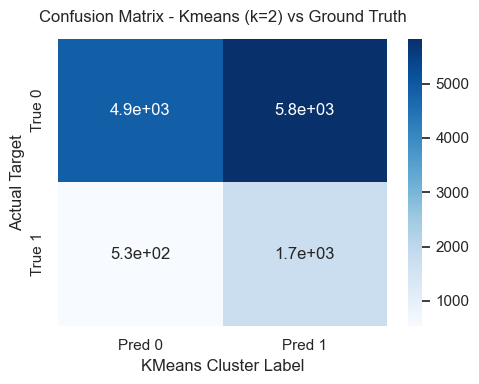


Classification Report:
                           precision    recall  f1-score   support

Class 0 (not seeking job)       0.90      0.46      0.60     10695
   Class 1 (seeking jobs)       0.23      0.77      0.35      2282

                 accuracy                           0.51     12977
                macro avg       0.57      0.61      0.48     12977
             weighted avg       0.78      0.51      0.56     12977

Total misclassifications : 6360 out of 12977  (49.01%)


In [16]:
# Pull out our two label arrays for comparison
y_true = df['target_int']           # ground truth (actual labels)
y_pred = df['cluster_label']        # what KMeans predicted

# Confusion Matrix
# rows = actual class (target_int)
# cols = predicted class (cluster_label)
# correct assignments appear on the main diagonal
cm = confusion_matrix(y_true, y_pred)

print("Confused Matrix (rows = actual, cols = predicted):")
print(cm)

# Visualize the confusion matrix as a heatmap for easier reading
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,             # print the count number inside each cell
    cmap='Blues',           # light-to-dark blue color scheme
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['True 0', 'True 1'],
    ax=ax
)

ax.set_title('Confusion Matrix - Kmeans (k=2) vs Ground Truth', pad=12)
ax.set_xlabel('KMeans Cluster Label')
ax.set_ylabel('Actual Target')
plt.tight_layout()
plt.show()

# Classification Report
# Shows precision, recall, and F1-score for each class
# precision → of all points labeled as class X, how many actually are X
# recall    → of all actual class X points, how many did we correctly find
# f1-score  → harmonic mean of precision and recall

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=['Class 0 (not seeking job)', 'Class 1 (seeking jobs)']
))

# Total Misclassifications 
# A misclassification is any row where cluster_label does not equal target_int
misclassified = (y_true != y_pred).sum()
total = len(y_true)
print(f"Total misclassifications : {misclassified} out of {total}  "
      f"({100 * misclassified / total:.2f}%)")


### Section 3.9 – Discussion of Confusion Matrix Results
...

### Section 3.10 – Show the Inertia of the Cluster

Inertia (also called Within-Cluster Sum of Squares, WCSS) is the sum of 
squared distances from each point to its assigned cluster center.
Lower inertia means tighter and more compact clusters.

In [17]:
# kmeans.inertia_ stores the final WCSS value after the model converged
# this is automatically computed and stored when we called kmeans.fit()
print(f"Inertia (WCSS) for K=2 : {kmeans.inertia_:.4f}")
print(
    "\nThis is the total sum of squared Euclidean distances from each "
    "sample to its nearest cluster center in the scaled feature space. "
    "We use this value as our benchmark when plotting the elbow curve below."
)

Inertia (WCSS) for K=2 : 49643.7946

This is the total sum of squared Euclidean distances from each sample to its nearest cluster center in the scaled feature space. We use this value as our benchmark when plotting the elbow curve below.


### Section 3.11 – Discussion of Elbow Method 
Q : What is the elbow method and what is its purpose of it in the case of KMeans clustering?

...

### Section 3.12 – Plot Inertia for k = 2 to 20 (Elbow Curve)

Although we chose k=2 for our main model, we run KMeans for every k from 
2 to 20 and plot inertia vs k to see what the elbow curve looks like.

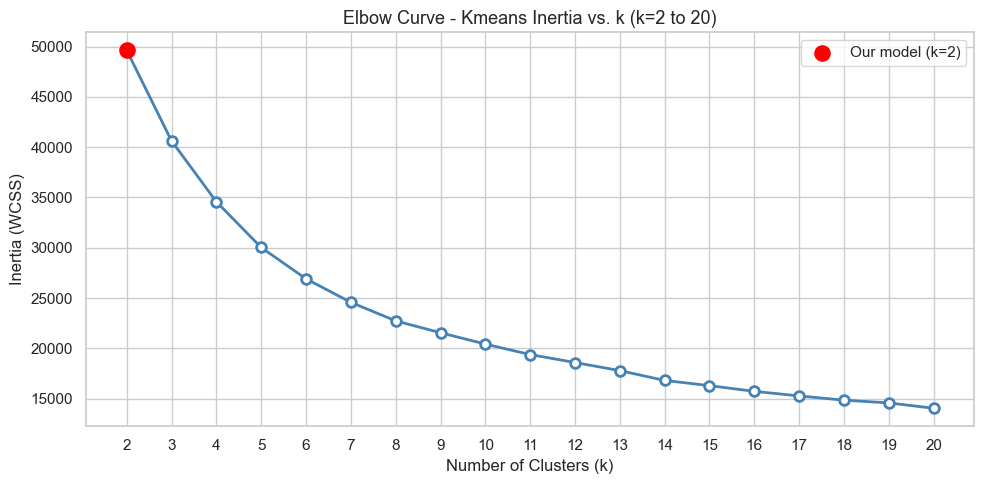

  k    | Inertia
----------------------
  2  |   49643.7946
  3  |   40632.6795
  4  |   34578.8364
  5  |   30028.4924
  6  |   26914.2275
  7  |   24573.9022
  8  |   22730.0520
  9  |   21550.5984
 10  |   20419.1657
 11  |   19379.7958
 12  |   18587.1582
 13  |   17784.7533
 14  |   16806.6220
 15  |   16287.0964
 16  |   15720.4058
 17  |   15264.2394
 18  |   14844.4257
 19  |   14571.5660
 20  |   14037.5031


In [18]:
# We will train a separate KMeans model for each k from 2 to 20
# and record the inertia each time
k_values = range(2,21)  # k = 2, 3, 4, ... 20
inertias = []           # empty list to collect inertia for each k

for k in k_values:
    # Use the same settings as our main model for fair comparison
    km_temp = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=47
    )
    km_temp.fit(X_scaled)

    # .inertia_ holds the WCSS for this particular k
    inertias.append(km_temp.inertia_)

# PLOT THE ELBOW CURVE
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    list(k_values), inertias,
    marker='o',                # place a dot at each k value
    linewidth=2,
    color='steelblue',
    markersize=7,
    markerfacecolor='white',
    markeredgewidth=2 
)

# Highlight our chosen k=2 with a red dot so it stands out
ax.scatter(
    [2], [inertias[0]],
    color='red',
    zorder=5,
    s=120,
    label='Our model (k=2)'
)

ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (WCSS)', fontsize=12)
ax.set_title('Elbow Curve - Kmeans Inertia vs. k (k=2 to 20)', fontsize=13)
ax.set_xticks(list(k_values))
ax.legend()
plt.tight_layout()
plt.show()

# Print the raw numbers for reference
print(f"{'k':>3}    | Inertia")
print("-"*22)
for k, iner in zip(k_values, inertias):
    print(f"{k:>3}  |   {iner:.4f}")



### Section 3.13 – Scatter Plot: Training Hours vs Experience (Colored by Cluster)

We plot training_hours on the x-axis and experience on the y-axis.
Each point is colored based on which cluster KMeans assigned it to.
This lets us visually see how well the two clusters separate in this 2D space.

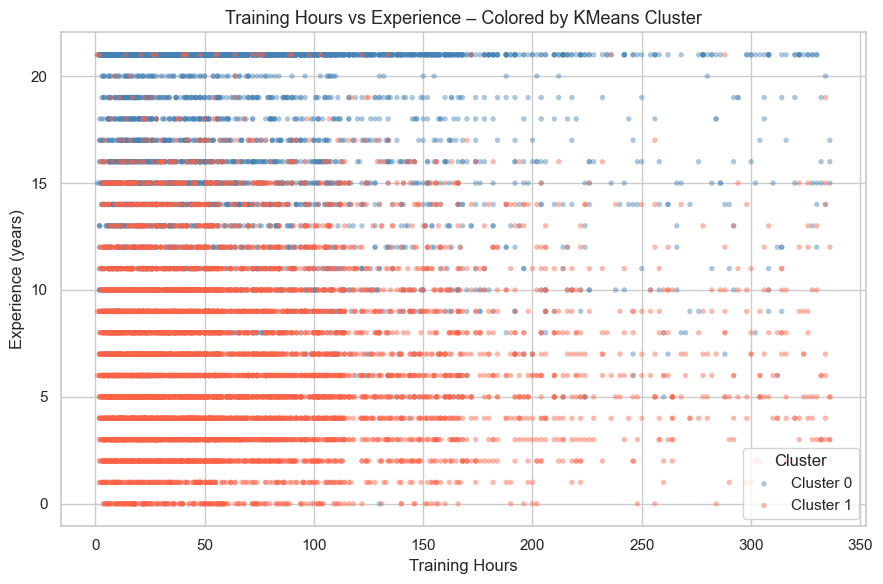

In [19]:
# Define colors for each cluster label
# Cluster 0 → steelblue,  Cluster 1 → tomato
palette = {0: 'steelblue', 1: 'tomato'}

fig, ax = plt.subplots(figsize=(9, 6))

# Loop through each cluster group and plot its points separately
# so we can assign a different color and add a legend entry per cluster
for label, grp in df.groupby('cluster_label'):
    ax.scatter(
        grp['training_hours'],   # x-axis
        grp['experience'],       # y-axis
        c=palette[label],        # color based on cluster
        label=f'Cluster {label}',
        alpha=0.45,              # slight transparency so overlapping points show
        s=15,                    # point size
        edgecolors='none'        # no outline on dots for cleaner look
    )

# These MUST be outside the loop — set them once after all points are plotted
ax.set_xlabel('Training Hours', fontsize=12)
ax.set_ylabel('Experience (years)', fontsize=12)
ax.set_title('Training Hours vs Experience – Colored by KMeans Cluster', fontsize=13)
ax.legend(title='Cluster', fontsize=11)
plt.tight_layout()
plt.show()

### Section 3.13 Discussion on Training Hours vs Experience Plot
...

### Section 3.14 – Scatter Plot: City Development Index vs Training Hours (Colored by Cluster)

We choose city_development_index and training_hours as our second pair of 
features to visualize. The city development index is interesting because it 
represents how urban and developed a candidate's city is, which may relate 
to job market access and job-seeking behavior.

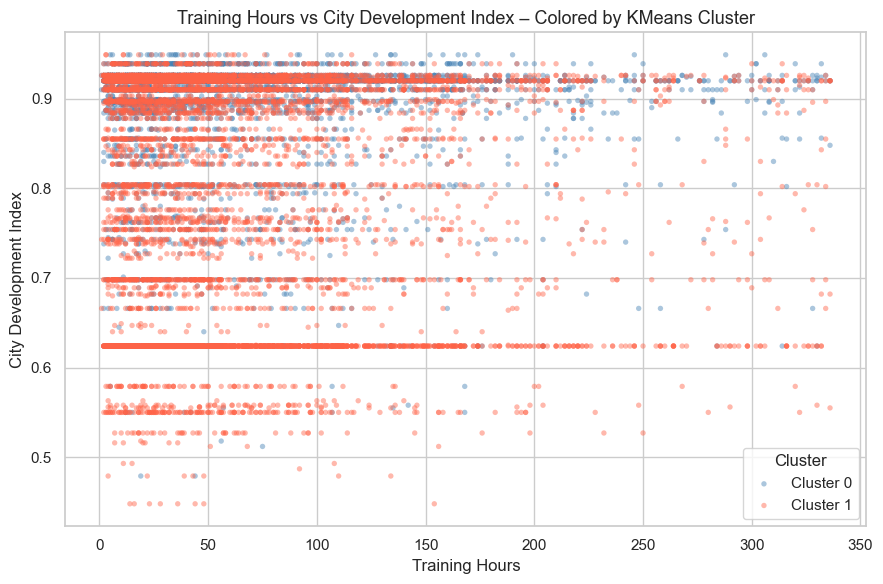

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))

for label, grp in df.groupby('cluster_label'):
    ax.scatter(
        grp['training_hours'],          # x-axis
        grp['city_development_index'],  # y-axis
        c=palette[label],
        label=f'Cluster {label}',
        alpha=0.45,
        s=15,
        edgecolors='none'
    )

# These MUST be outside the loop — set them once after all points are plotted
ax.set_xlabel('Training Hours', fontsize=12)
ax.set_ylabel('City Development Index', fontsize=12)
ax.set_title('Training Hours vs City Development Index – Colored by KMeans Cluster', fontsize=13)
ax.legend(title='Cluster', fontsize=11)
plt.tight_layout()
plt.show()

### Section 3.14 - Discussion on City Development Index vs Training Hours Plot
...

## Section 4 – Agglomerative Clustering (15 pts)

Agglomerative clustering is a hierarchical bottom-up approach.
It starts with every single data point in its own cluster.
At each step it merges the two closest clusters until we reach 
the desired number of clusters k.

We will visualize this process with a dendrogram, then run the 
clustering with k=2 and k=4 and compare the results.

### Section 4.1 – Plot the Dendrogram

A dendrogram is a tree diagram that shows the entire merging history of 
agglomerative clustering. Each leaf is a data point. The height at which 
two branches merge represents how different those clusters are.

A large vertical gap before a merge means those clusters are very dissimilar — 
cutting the tree there gives us a natural number of clusters to use.

Because we have ~13,000 samples, plotting the full dendrogram is not readable.
We subsample 3,000 points and show only the top levels of the tree.

Linkage matrix shape: (2999, 4)
(should be (2999, 4) = one merge per step)


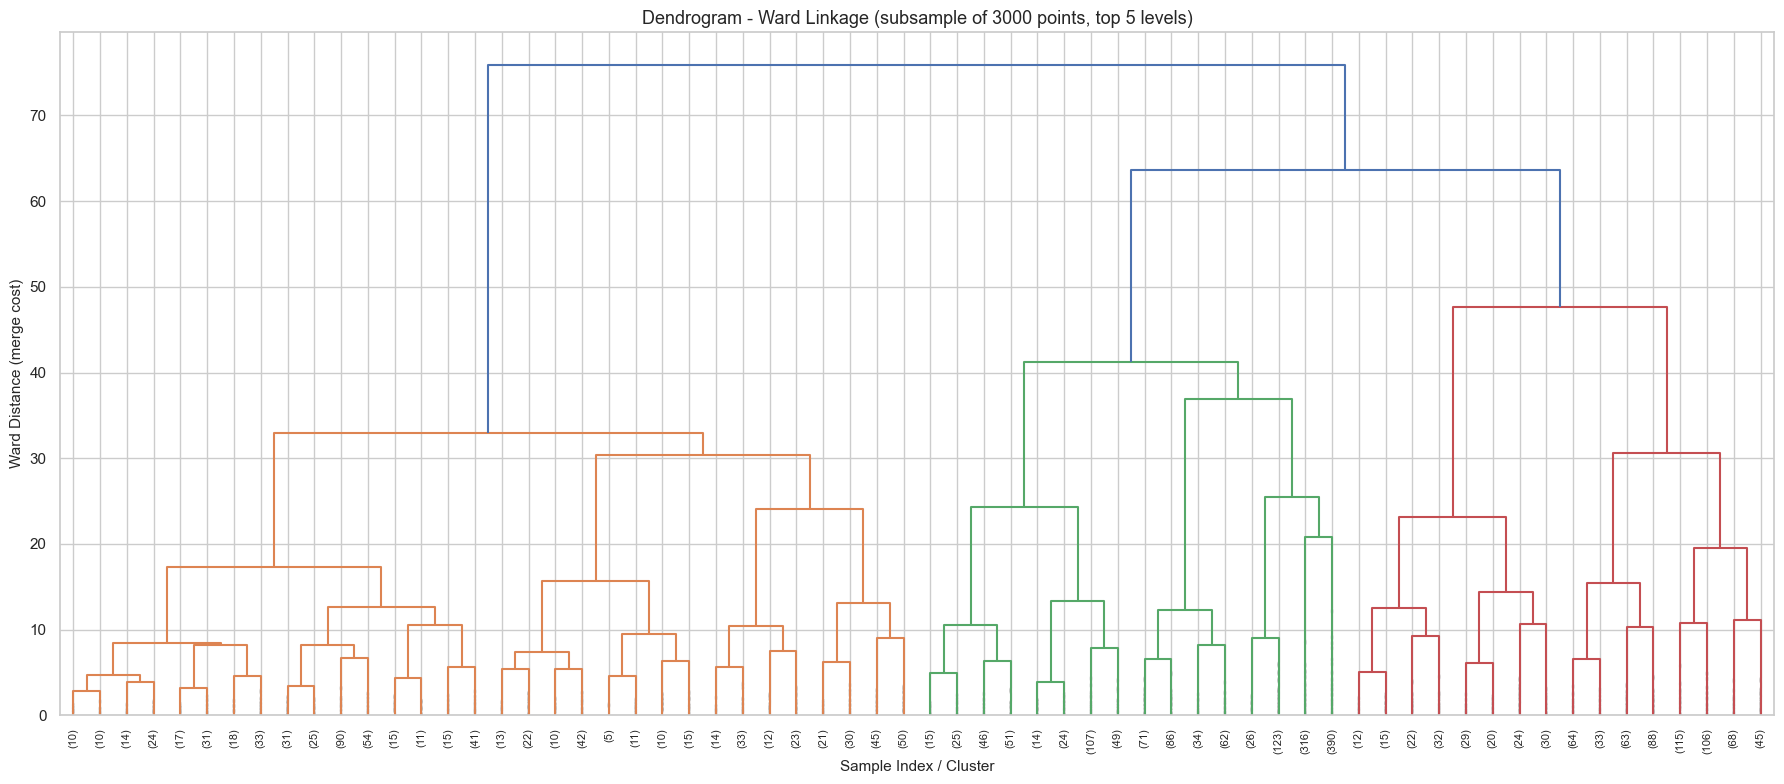

In [21]:
# Subsample 3000 rows because computing the full linkage matrix for all
# ~13,000 rows would be very slow and the plot would be completely unreadable
N_SAMPLE = 3000
np.random.seed(47)          # fix seed for reproducibility
sample_idx = np.random.choice(len(X_scaled), size=N_SAMPLE, replace=False)
X_sample = X_scaled.iloc[sample_idx].values

# linkage() computes the hierarchical merging steps
# method='ward'      → at each step merge the pair that minimizes
#                      the increase in total within-cluster variance
# metric='euclidean' → use Euclidean distance between points
# this produces a (N_SAMPLE-1, 4) matrix where each row records one merge
Z = linkage(X_sample, method='ward', metric='euclidean')

print(f"Linkage matrix shape: {Z.shape}")
print(f"(should be ({N_SAMPLE - 1}, 4) = one merge per step)")

# DRAW THE DENDROGRAM
fig, ax = plt.subplots(figsize=(18,8))  # large figure - still won't show all leaves

dendrogram(
    Z,
    ax=ax,
    truncate_mode='level',      # only show the top levels instead of all leaves
    p=5,                        # show top 5 levels of the tree
    leaf_rotation=90,           # rotate the labels so they don't overlap
    leaf_font_size=8,           # smaller font to fit more labels
    show_contracted=True,       # show a triangle where branches were collapsed
)

ax.set_title(f'Dendrogram - Ward Linkage (subsample of {N_SAMPLE} points, top 5 levels)', fontsize=13)
ax.set_xlabel('Sample Index / Cluster', fontsize=11)
ax.set_ylabel('Ward Distance (merge cost)', fontsize=11)
plt.tight_layout()
plt.show()

### Section 4.2 – Agglomerative Clustering with k = 2

We run AgglomerativeClustering with:
- n_clusters = 2    → same as our KMeans experiment so we can compare
- metric = 'euclidean' → measure distance between points using straight-line distance
- linkage = 'ward'  → merge clusters that minimize the increase in WCSS
                      this is the same criterion as the dendrogram above

In [22]:
# AgglomerativeClustering does NOT have a predict() method
# it can only assign labels to the data it was trained on
# fit_predict() fits the model and returns the cluster labels in one step
agg2 = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='ward'
)

agg2_labels = agg2.fit_predict(X_scaled)

# Store the labels back in the DataFrame so we can use them for plotting
df['agg2_label'] = agg2_labels

print("Agglomerative (k=2) label distribution:")
unique, counts = np.unique(agg2_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"    Cluster {u}: {c} samples ({100 * c / len(agg2_labels):.1f}%)")

Agglomerative (k=2) label distribution:
    Cluster 0: 9966 samples (76.8%)
    Cluster 1: 3011 samples (23.2%)


### Section 4.3 – Scatter Plot: Training Hours vs Experience (Agglomerative k=2)

We recreate the same scatter plot from Section 3.xiii using the Agglomerative 
cluster labels so we can directly compare the two algorithms side by side.

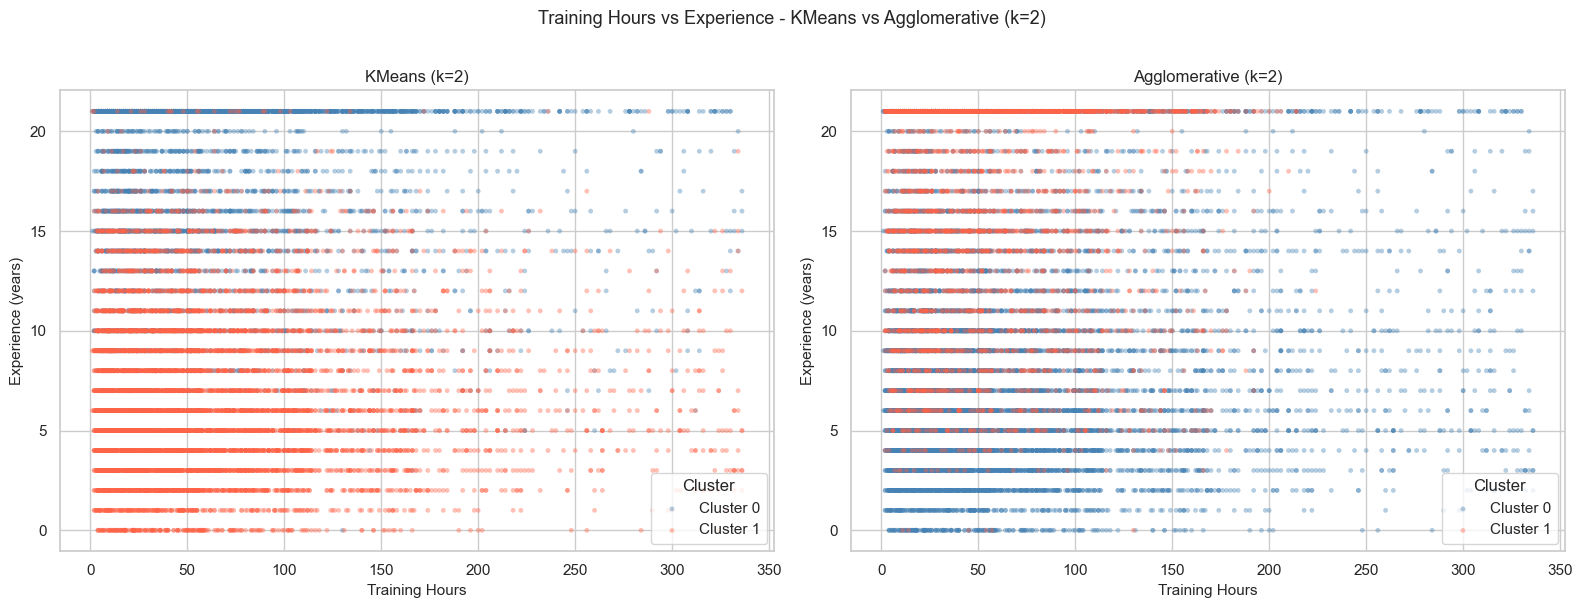

In [23]:

# Plot both clustering results side by side in one figure for easy comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define what we want to plot in each subplot
plot_configs = [
    ('cluster_label',   'KMeans (k=2)'),
    ('agg2_label',      'Agglomerative (k=2)')
]

for ax, (col, title) in zip(axes, plot_configs):
    for label, grp in df.groupby(col):
        ax.scatter(
            grp['training_hours'],
            grp['experience'],
            c=palette[label],
            label=f'Cluster {label}',
            alpha=0.40,
            s=12,
            edgecolors='none'
        )
    ax.set_xlabel('Training Hours', fontsize=11)
    ax.set_ylabel('Experience (years)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(title='Cluster')

plt.suptitle(
    'Training Hours vs Experience - KMeans vs Agglomerative (k=2)', fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()


#### Section 4.3 Discussion – Agglomerative k=2 vs KMeans k=2
...

### Section 4.4 – Agglomerative Clustering with k = 4

We increase the number of clusters to 4 to see if finer sub-groups emerge 
within the data. We then plot the results against k=2 to compare how the 
extra clusters subdivide the original two groups.

Agglomerative (k=4) label distribution:
    Cluster 0: 5807 samples (44.7%)
    Cluster 1: 3011 samples (23.2%)
    Cluster 2: 3117 samples (24.0%)
    Cluster 3: 1042 samples (8.0%)


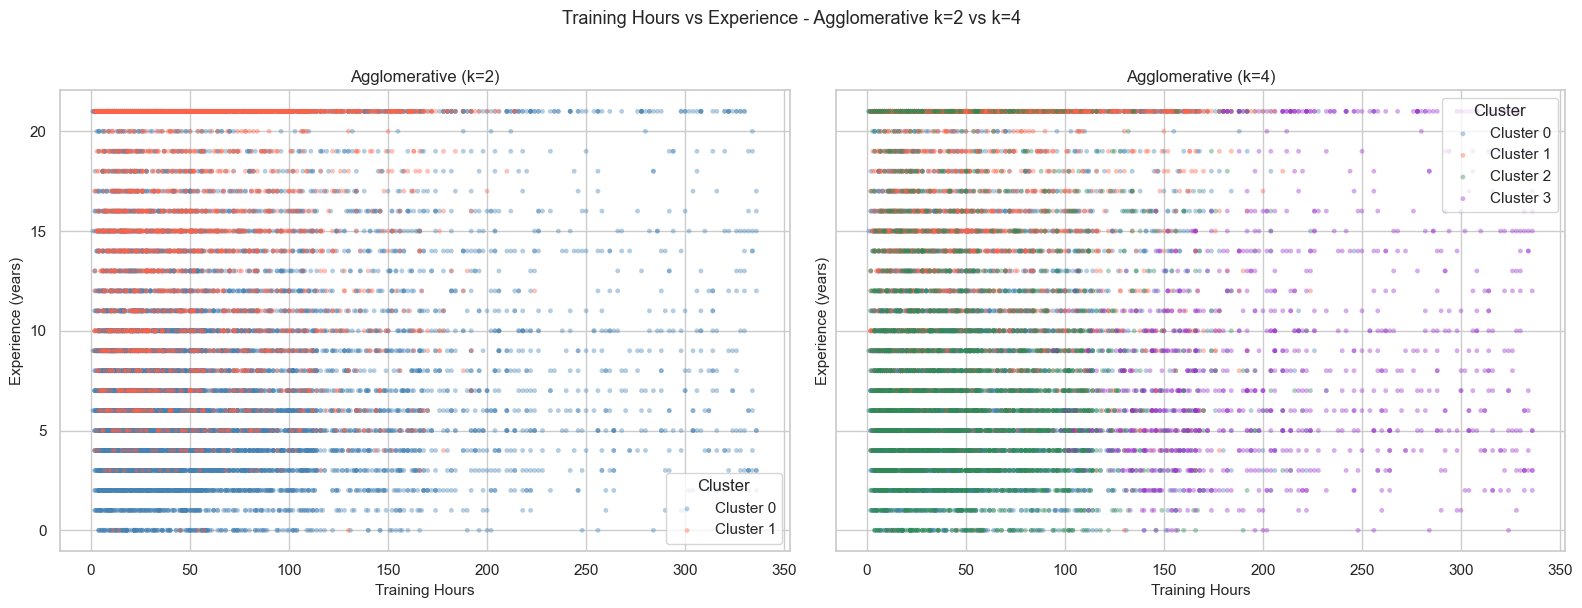

In [24]:
K_AGG = 4   # Increase to 5 here if you want to try k=5 instead 

agg4 = AgglomerativeClustering(
    n_clusters=K_AGG,
    metric='euclidean',
    linkage='ward'
)

agg4_labels = agg4.fit_predict(X_scaled)
df['agg4_label'] = agg4_labels

print(f"Agglomerative (k={K_AGG}) label distribution:")
unique, counts = np.unique(agg4_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"    Cluster {u}: {c} samples ({100* c / len(agg4_labels):.1f}%)")

# side by side plot: K=2 vs k=4

# We need a 4-color palette for the k=4 plot
palette4 = {0: 'steelblue', 1: 'tomato', 2: 'seagreen', 3: 'darkorchid'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

plot_configs4=[
    ('agg2_label', 'Agglomerative (k=2)'),
    ('agg4_label', f'Agglomerative (k={K_AGG})')
]

for ax, (col, title) in zip(axes, plot_configs4):
    for label in sorted(df[col].unique()):
        grp=df[df[col] == label]
        ax.scatter(
            grp['training_hours'],
            grp['experience'],
            c=palette4[label],
            label=f'Cluster {label}',
            alpha=0.40,
            s=12,
            edgecolors='none'
        )
    ax.set_xlabel('Training Hours', fontsize=11)
    ax.set_ylabel('Experience (years)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(title='Cluster')

plt.suptitle(
    f'Training Hours vs Experience - Agglomerative k=2 vs k={K_AGG}',
    fontsize=13,
    y=1.01
)

plt.tight_layout()
plt.show()


#### Section 4.4 Discussion – Increasing to k = 4